# 训练后模型推理与可视化

本笔记本演示如何使用 `qwen3smvl/inference/inference_vl_model.py` 中定义的 `VLModelInference` 对已经训练好的模型检查点进行推理，并对生成结果进行可视化展示。

笔记本组织如下：

| Section | 内容 |
|---|---|
| 1 | 在 **DanQing** 数据集的测试分片上运行推理，并可视化图像、prompt、预测输出与参考答案 |
| 2 | 通过 `train.py` 的 `load_mixed_data_v2` 加载 **其他数据源** 的测试样本（例如 AlignMMBench），复用同一模型进行推理并可视化 |

**模型检查点**：`./model/unfreeze_connector_pretraining_test`


## 0. 环境与路径准备

In [1]:
import sys
print('Python executable:', sys.executable)
print('Python version   :', sys.version.split()[0])

try:
    import transformers, accelerate
    print(f'transformers     : {transformers.__version__}')
    print(f'accelerate       : {accelerate.__version__}')
    from transformers import Trainer  # noqa: F401
    print('Trainer import   : OK')
except Exception as e:
    print('Trainer import   : FAIL →', type(e).__name__, e)
    print('\n→ Kernel is NOT using the project .venv, OR accelerate is missing there.')
    print('  Fix: in VSCode/Cursor, click the kernel picker (top-right of notebook)')
    print('       and select  .venv\\Scripts\\python.exe  under this project root.')

Python executable: e:\cursorprojects\Qwen3-SmVL\.venv\Scripts\python.exe
Python version   : 3.12.13


e:\cursorprojects\Qwen3-SmVL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\cursorprojects\Qwen3-SmVL\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


transformers     : 4.56.2
accelerate       : 1.10.1
Trainer import   : OK


In [2]:
import os, sys, logging, random
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'CWD          = {os.getcwd()}')

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger('inference_demo')
logging.getLogger('inference_vl_model').setLevel(logging.WARNING)

PROJECT_ROOT = E:\cursorprojects\Qwen3-SmVL
CWD          = E:\cursorprojects\Qwen3-SmVL


In [3]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import textwrap

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    total_bytes = torch.cuda.get_device_properties(0).total_memory
    # 厂商标注的 "24 GB" 实际是二进制 GiB (2^30 bytes)；
    # 直接 / 1e9 得到 ~25.77 是 decimal GB，数值看起来偏大。
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {total_bytes / (1024 ** 3):.2f} GiB  '
          f'({total_bytes / 1e9:.2f} GB decimal)')

try:
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
except Exception as _e:
    print('字体设置警告:', _e)

Device: cuda:0
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
VRAM: 23.89 GiB  (25.65 GB decimal)


### 可视化工具

封装一个 `show_sample` 工具，在一张 matplotlib figure 中同时展示：图像、用户 prompt、模型预测结果、参考答案（若有）。

In [4]:
def _to_pil(img):
    """归一化各种输入格式到 PIL.Image.Image。"""
    if isinstance(img, Image.Image):
        return img.convert('RGB')
    if isinstance(img, dict):
        if img.get('bytes'):
            return Image.open(BytesIO(img['bytes'])).convert('RGB')
        if img.get('path'):
            return Image.open(img['path']).convert('RGB')
    if isinstance(img, (bytes, bytearray)):
        return Image.open(BytesIO(img)).convert('RGB')
    if isinstance(img, str):
        return Image.open(img).convert('RGB')
    raise TypeError(f'无法识别的图像类型: {type(img)}')


def _wrap(text: str, width: int = 60) -> str:
    if text is None:
        return ''
    text = str(text).strip()
    return '\n'.join(textwrap.wrap(text, width=width, replace_whitespace=False, drop_whitespace=False) or [''])


def show_sample(image, prompt: str, prediction: str, reference: str = None,
                title: str = '', figsize=(12, 6)):
    """在同一张 figure 里并排展示图像和文本对比。"""
    pil_img = _to_pil(image)

    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [1, 1.3]})
    ax_img.imshow(pil_img)
    ax_img.set_axis_off()
    if title:
        ax_img.set_title(title, fontsize=11)

    ax_txt.set_axis_off()
    parts = [f'【Prompt】\n{_wrap(prompt)}', f'\n【Prediction】\n{_wrap(prediction)}']
    if reference:
        parts.append(f'\n【Reference】\n{_wrap(reference)}')
    ax_txt.text(0.0, 1.0, '\n'.join(parts), va='top', ha='left', fontsize=10, family='sans-serif', wrap=True)

    plt.tight_layout()
    plt.show()

## 1. DanQing 测试集推理与可视化

步骤：

1. 通过 `load_mixed_data_v2` 读取 `scripts/mixture/danqing.json` 定义的 DanQing 子集，取其中的 `test` 分片作为评测池；
2. 使用 `inference_vl_model.VLModelInference` 初始化模型，并加载训练后的权重；
3. 对选定数量的样本逐条调用 `generate`，收集预测；
4. 调用 `show_sample` 可视化每条样本。


In [5]:
from qwen3smvl.train.train import load_mixed_data_v2

DANQING_MIX = [
    {
        'source': 'danqing',
        'path':   'data/DanQing/data/train-*.parquet',
        'count':  10000,
        'label':  'DanQing',
    }
]

danqing_raw = load_mixed_data_v2(
    dataset_mix=DANQING_MIX,
    seed=42,
    test_size=3000,
)
danqing_test = danqing_raw['test']
print(f'DanQing test split: {len(danqing_test)} samples')
print('columns:', danqing_test.column_names)
print('first sample texts:', danqing_test[0]['texts'])

2026-05-08 17:39:32,507 [INFO] 
Loading dataset mix...
2026-05-08 17:39:32,507 [INFO]   ↳ [DanQing]  source=danqing  target=10000
2026-05-08 17:39:32,718 [INFO]     35 parquet file(s), 105,000 total rows (from metadata)
2026-05-08 17:39:32,718 [INFO]     Fetching 10,000 samples from 35 of 35 file(s)
2026-05-08 17:39:33,961 [INFO]     ... 3/35 files processed (854 rows so far)
2026-05-08 17:39:35,161 [INFO]     ... 6/35 files processed (1,724 rows so far)
2026-05-08 17:39:36,409 [INFO]     ... 9/35 files processed (2,639 rows so far)
2026-05-08 17:39:37,694 [INFO]     ... 12/35 files processed (3,502 rows so far)
2026-05-08 17:39:38,935 [INFO]     ... 15/35 files processed (4,378 rows so far)
2026-05-08 17:39:40,121 [INFO]     ... 18/35 files processed (5,224 rows so far)
2026-05-08 17:39:41,242 [INFO]     ... 21/35 files processed (6,068 rows so far)
2026-05-08 17:39:42,579 [INFO]     ... 24/35 files processed (6,879 rows so far)
2026-05-08 17:39:43,741 [INFO]     ... 27/35 files proce

DanQing test split: 3000 samples
columns: ['images', 'texts']
first sample texts: [{'user': '请用文字描述你在图片中看到的一切。', 'assistant': '游戏场景中，左侧角色持剑，右侧骷髅角色持斧，背景为绿色方块。', 'source': 'DanQing'}]


In [6]:
from qwen3smvl.inference.inference_vl_model import VLModelInference

CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, 'model', 'unfreeze_connector_pretraining_full')
# CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, 'model', 'full_tuning')
print(f'CHECKPOINT_PATH = {CHECKPOINT_PATH}')
assert os.path.exists(os.path.join(CHECKPOINT_PATH, 'model.safetensors')), \
    f'未在 {CHECKPOINT_PATH} 找到 model.safetensors，请确认训练产物路径'

vl_infer = VLModelInference(
    model_or_checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    enable_csv=False,   # 笔记本中不需要 shape CSV 日志
)

2026-05-08 17:39:54,081 [INFO] 正在加载训练后的模型: E:\cursorprojects\Qwen3-SmVL\model\unfreeze_connector_pretraining_full
2026-05-08 17:39:54,081 [INFO] 正在加载SmolVLM2视觉-语言模型...
`torch_dtype` is deprecated! Use `dtype` instead!


CHECKPOINT_PATH = E:\cursorprojects\Qwen3-SmVL\model\unfreeze_connector_pretraining_full


2026-05-08 17:39:54,670 [INFO] 正在加载Qwen3语言模型...
2026-05-08 17:39:55,414 [INFO] 正在构建连接器配置...
2026-05-08 17:39:55,414 [INFO] 正在创建新的连接器...
2026-05-08 17:39:55,481 [INFO] 正在替换语言模型组件...
2026-05-08 17:39:55,481 [INFO] 正在更新模型配置...
2026-05-08 17:39:55,481 [INFO] 模型构建完成！
2026-05-08 17:39:55,481 [INFO] 正在加载SmolVLM2处理器...
2026-05-08 17:39:55,664 [INFO] 正在加载Qwen3分词器...
2026-05-08 17:39:55,956 [INFO]   添加前词表大小: 151669
2026-05-08 17:39:55,958 [INFO]   已新增 36 个位置特殊token（<row_i_col_j>）
2026-05-08 17:39:55,958 [INFO]   添加后词表大小: 151705
2026-05-08 17:39:55,958 [INFO] 正在配置处理器...
2026-05-08 17:39:55,960 [INFO]   图像处理器（来自 preprocessor_config.json）: size={'longest_edge': 2048}, max_image_size={'longest_edge': 512}, do_image_splitting=True
2026-05-08 17:39:55,960 [INFO] 正在加载safetensors权重...
2026-05-08 17:39:56,607 [INFO] ✅ 权重加载成功


In [7]:
def sample_to_io(sample):
    """把 load_mixed_data_v2 样本拆成 (image, prompt, reference) 三元组。"""
    img = sample['images'][0] if sample['images'] else None
    turn = sample['texts'][0] if sample['texts'] else {}
    return img, turn.get('user', ''), turn.get('assistant', '')


NUM_DANQING = min(5, len(danqing_test))
danqing_indices = list(range(NUM_DANQING))
print(f'将在 {NUM_DANQING} 条 DanQing 测试样本上运行推理: {danqing_indices}')

danqing_results = []
for i in danqing_indices:
    sample = danqing_test[i]
    image, prompt, reference = sample_to_io(sample)
    if image is None:
        print(f'[WARN] 样本 #{i} 没有图像，跳过')
        continue

    prediction = vl_infer.generate(
        images=image,
        prompts=prompt,
        max_new_tokens=2048,
        temperature=0.7,
        top_p=0.9,
        system_prompt="你是一个有帮助的语言与视觉助手。"
        "你能够理解用户提供的视觉内容，"
        "并使用自然语言协助用户完成各种任务。",
        enable_thinking=True,
        # 是否注入图像介绍 / 结尾文字（与训练 collator 同名参数对齐）。
        # 训练阶段开启该选项时，推理也应改为 True 以保持输入分布一致。
        add_media_intro_outro=False,
    )
    danqing_results.append({
        'index':      i,
        'image':      image,
        'prompt':     prompt,
        'prediction': prediction,
        'reference':  reference,
    })
    print(f'✔  sample {i}: 生成 {len(str(prediction))} 字')

print(f'\n完成 DanQing 推理，共 {len(danqing_results)} 条结果。')

2026-05-08 17:46:13,726 [INFO] Processed texts: <|im_start|>system
你是一个有帮助的语言与视觉助手。你能够理解用户提供的视觉内容，并使用自然语言协助用户完成各种任务。<|im_end|>
<|im_start|>user
<|image_pad|>
请用文字描述你在图片中看到的一切。<|im_end|>
<|im_start|>assistant

2026-05-08 17:46:13,726 [INFO] Batch image row shape before model processor:  1
2026-05-08 17:46:13,726 [INFO] total number of images in batch: 1


将在 5 条 DanQing 测试样本上运行推理: [0, 1, 2, 3, 4]


2026-05-08 17:46:14,021 [INFO] Batch image tensor shape after model processor: torch.Size([1, 13, 3, 512, 512])
2026-05-08 17:46:14,024 [INFO] Batch text tensor shape after model processor: torch.Size([1, 912])
2026-05-08 17:46:14,484 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 17:46:14,484 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 17:46:14,484 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 17:46:14,484 [INFO] Input: torch.Size([13, 1024, 768])
2026-05-08 17:46:14,484 [INFO] Output shape: torch.Size([13, 64, 1024])
2026-05-08 17:46:14,484 [INFO] Sequence length after connector: 64
2026-05-08 17:46:16,451 [INFO] Processed texts: <|im_start|>system
你是一个有帮助的语言与视觉助手。你能够理解用户提供的视觉内容，并使用自然语言协助用户完成各种任务。<|im_end|>
<|im_start|>user
<|image_pad|>
这幅图像呈现了哪些内容？<|im_end|>
<|im_start|>assistant

2026-05-08 17:46:16,451 [INFO] Batch image row s

✔  sample 0: 生成 67 字


2026-05-08 17:46:16,713 [INFO] Batch image tensor shape after model processor: torch.Size([1, 13, 3, 512, 512])
2026-05-08 17:46:16,716 [INFO] Batch text tensor shape after model processor: torch.Size([1, 910])
2026-05-08 17:46:16,736 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 17:46:16,736 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 17:46:16,736 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 17:46:16,739 [INFO] Input: torch.Size([13, 1024, 768])
2026-05-08 17:46:16,739 [INFO] Output shape: torch.Size([13, 64, 1024])
2026-05-08 17:46:16,740 [INFO] Sequence length after connector: 64
2026-05-08 17:46:18,588 [INFO] Processed texts: <|im_start|>system
你是一个有帮助的语言与视觉助手。你能够理解用户提供的视觉内容，并使用自然语言协助用户完成各种任务。<|im_end|>
<|im_start|>user
<|image_pad|>
这张图片里有什么？<|im_end|>
<|im_start|>assistant

2026-05-08 17:46:18,589 [INFO] Batch image row shap

...

✔  sample 2: 生成 48 字


2026-05-08 17:46:20,634 [INFO] Batch image tensor shape after model processor: torch.Size([1, 13, 3, 512, 512])
2026-05-08 17:46:20,634 [INFO] Batch text tensor shape after model processor: torch.Size([1, 912])
2026-05-08 17:46:20,650 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 17:46:20,651 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 17:46:20,651 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 17:46:20,651 [INFO] Input: torch.Size([13, 1024, 768])
2026-05-08 17:46:20,651 [INFO] Output shape: torch.Size([13, 64, 1024])
2026-05-08 17:46:20,651 [INFO] Sequence length after connector: 64
2026-05-08 17:46:22,395 [INFO] Processed texts: <|im_start|>system
你是一个有帮助的语言与视觉助手。你能够理解用户提供的视觉内容，并使用自然语言协助用户完成各种任务。<|im_end|>
<|im_start|>user
<|image_pad|>
说说看你在这张图片中看到了什么？<|im_end|>
<|im_start|>assistant

2026-05-08 17:46:22,395 [INFO] Batch image r

✔  sample 3: 生成 69 字


2026-05-08 17:46:22,726 [INFO] Batch image tensor shape after model processor: torch.Size([1, 17, 3, 512, 512])
2026-05-08 17:46:22,727 [INFO] Batch text tensor shape after model processor: torch.Size([1, 1177])
2026-05-08 17:46:22,748 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 17:46:22,750 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 17:46:22,750 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 17:46:22,750 [INFO] Input: torch.Size([17, 1024, 768])
2026-05-08 17:46:22,750 [INFO] Output shape: torch.Size([17, 64, 1024])
2026-05-08 17:46:22,751 [INFO] Sequence length after connector: 64


✔  sample 4: 生成 52 字

完成 DanQing 推理，共 5 条结果。


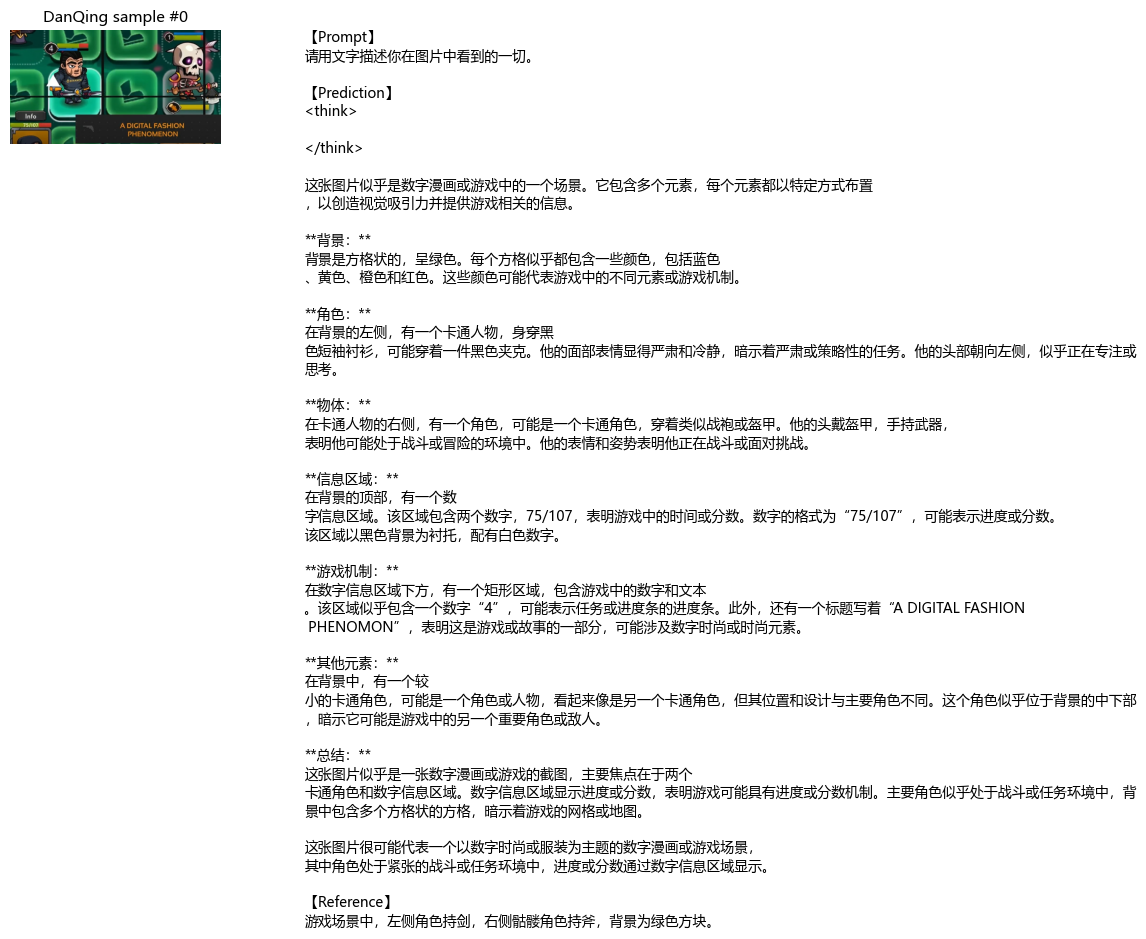

C:\Users\daniel\AppData\Local\Temp\ipykernel_23932\944339540.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


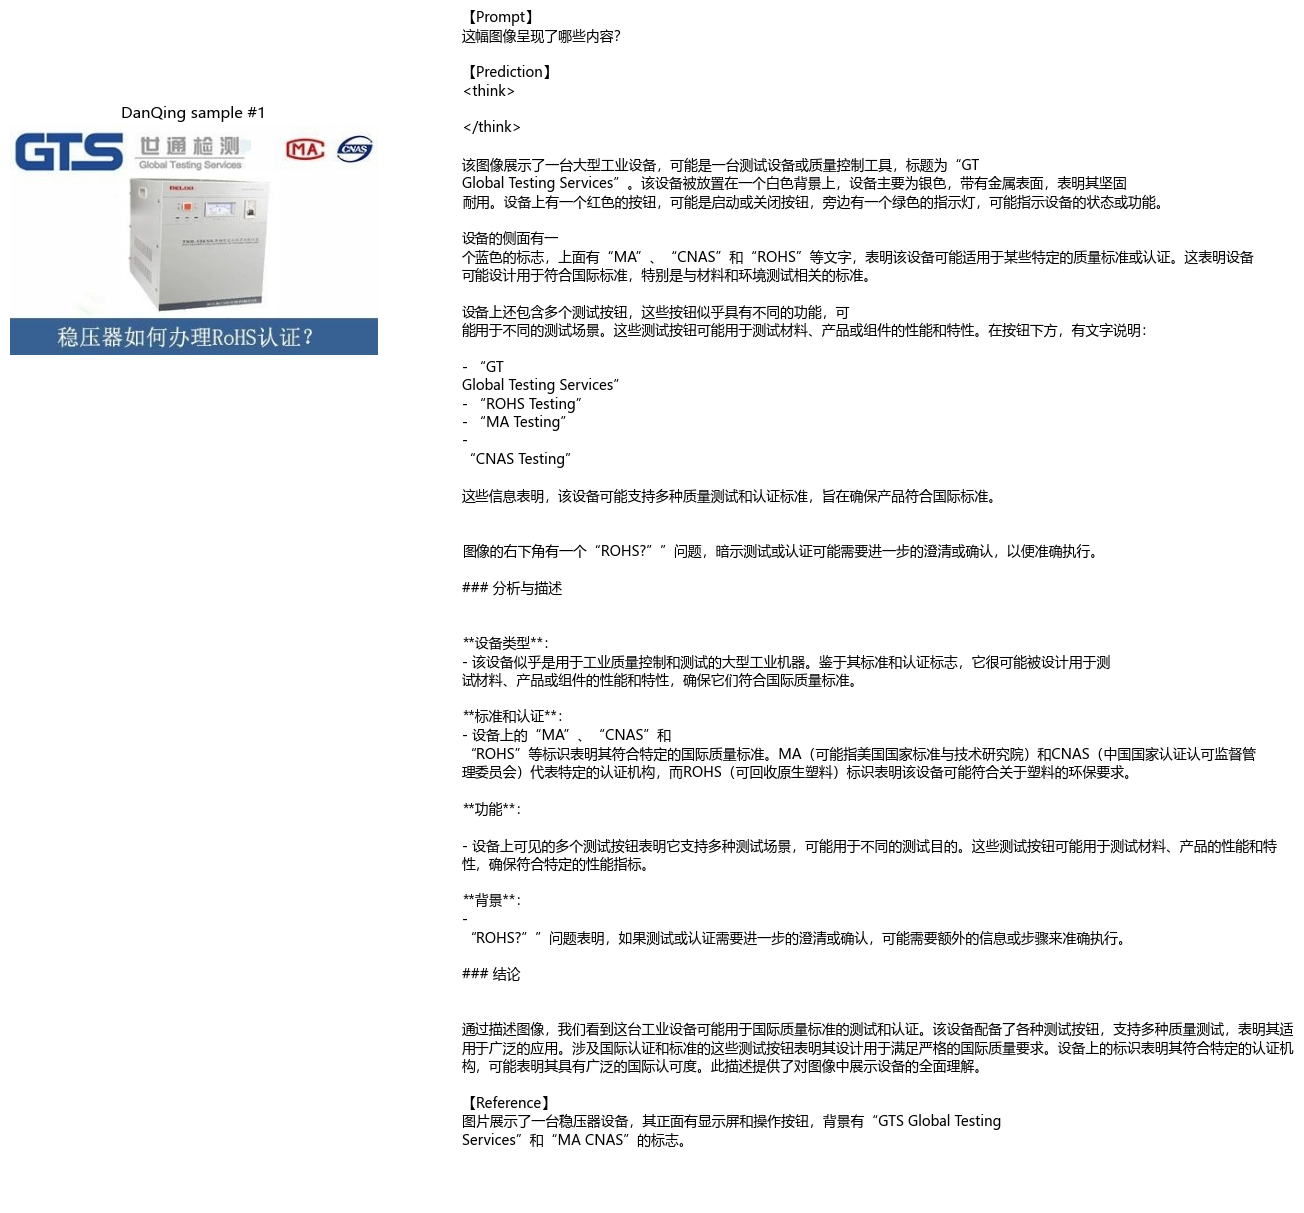

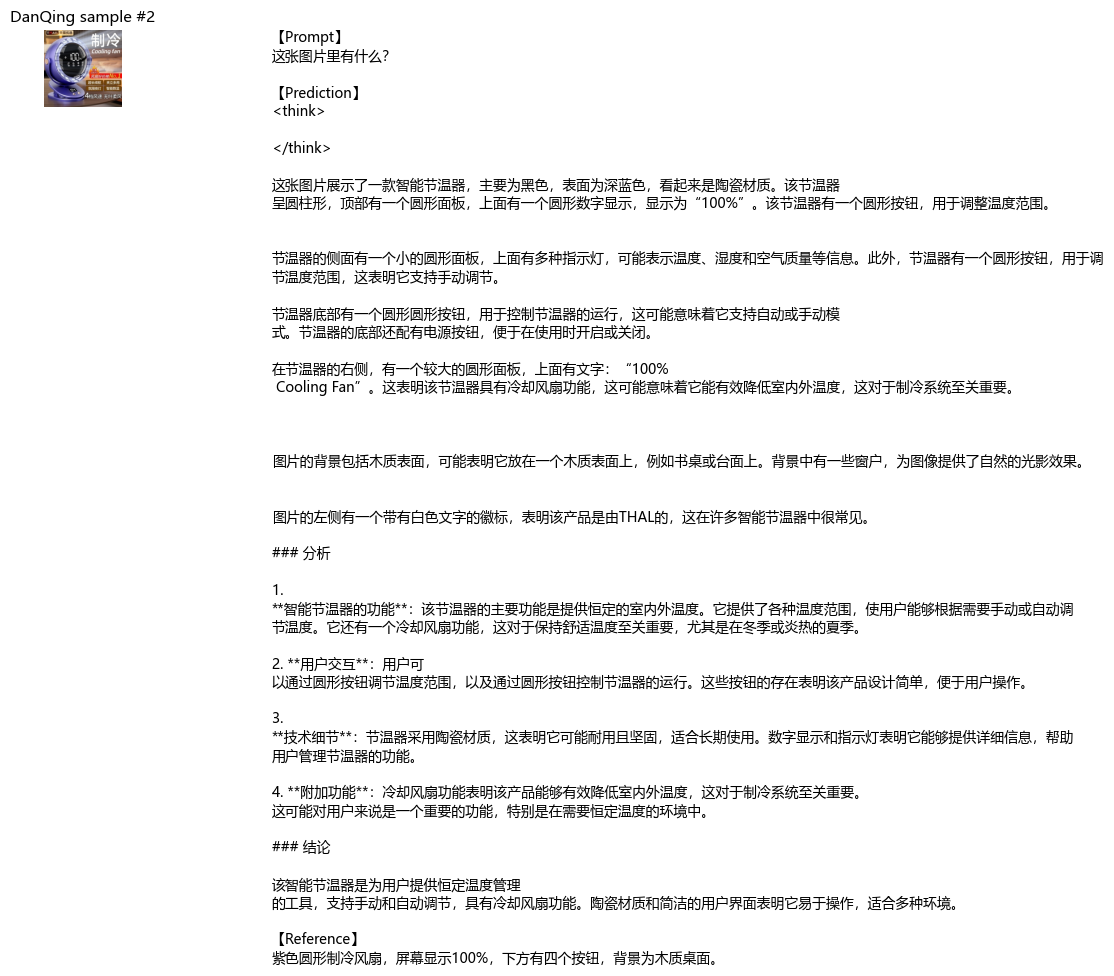

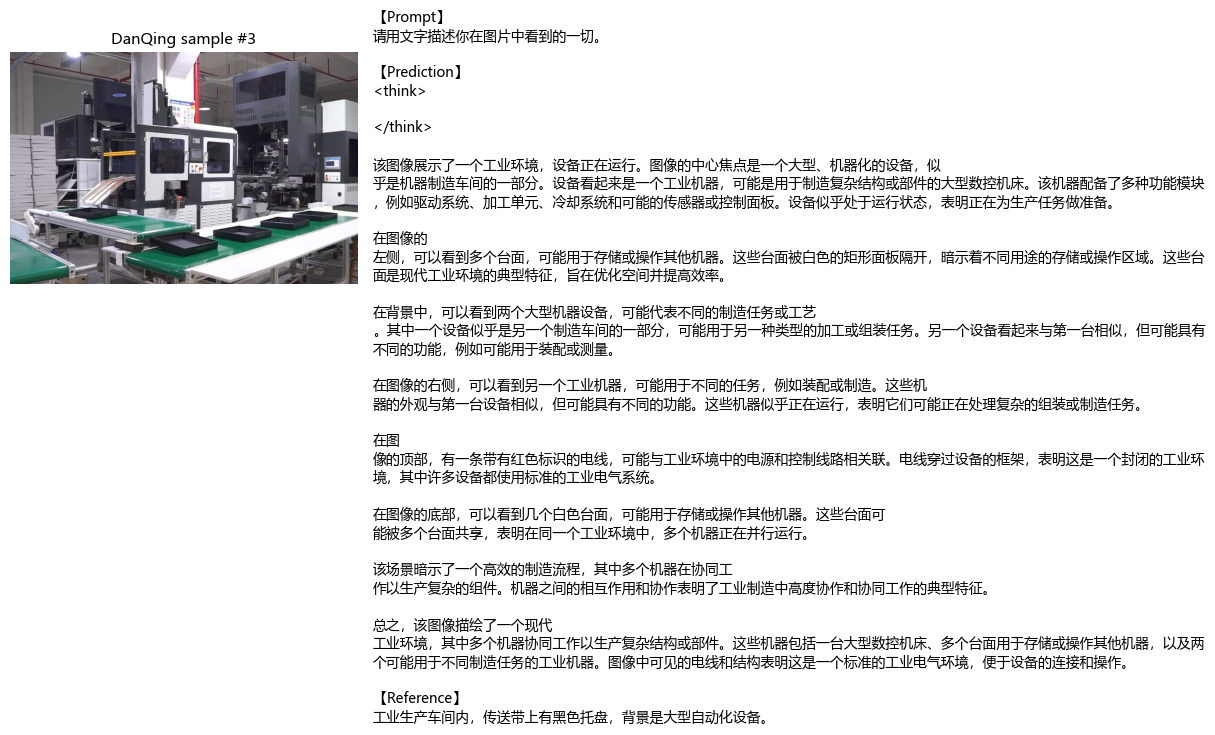

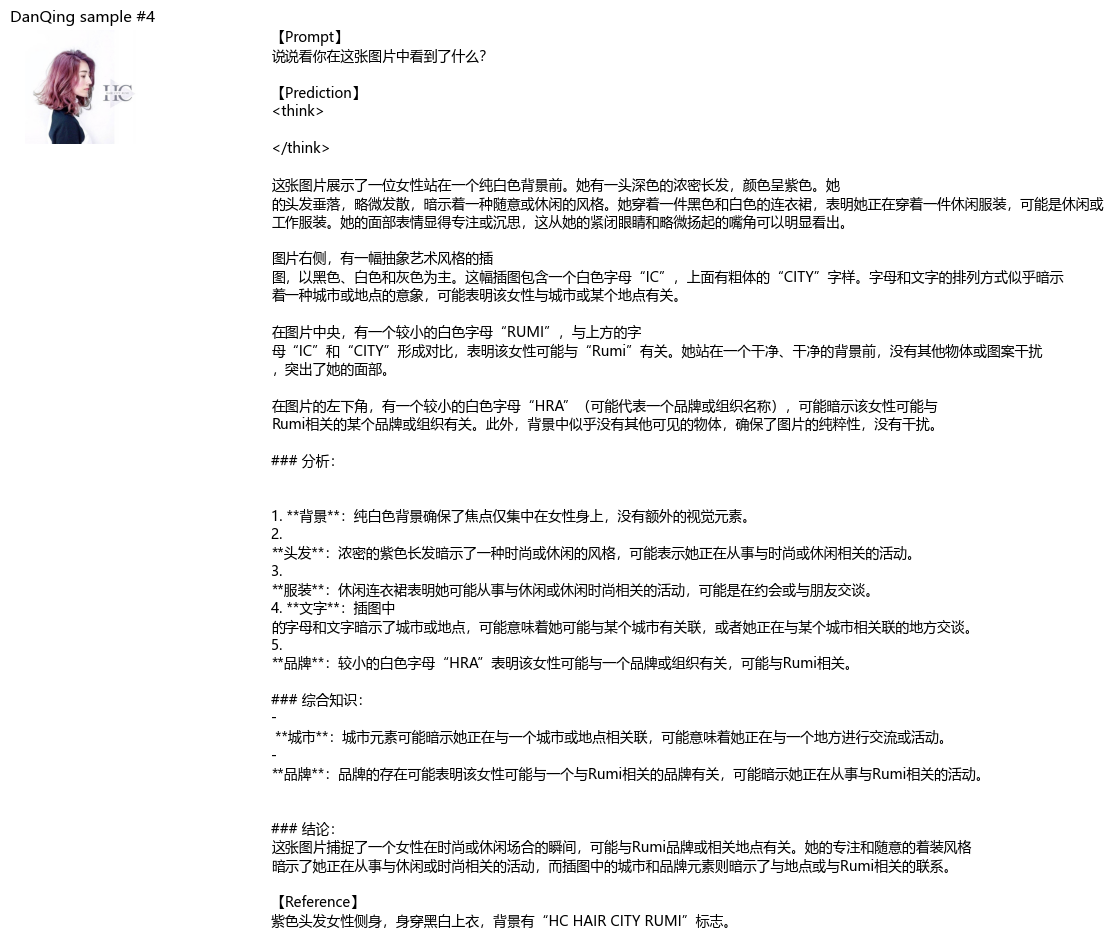

In [8]:
for r in danqing_results:
    show_sample(
        image=r['image'],
        prompt=r['prompt'],
        prediction=r['prediction'],
        reference=r['reference'],
        title=f"DanQing sample #{r['index']}",
    )

## 2. 其他测试集推理与可视化（`load_mixed_data_v2` 加载）

这里演示用 `load_mixed_data_v2` 以 **flat-QA JSONL** 的形式载入 `AlignMMBench`（你可以把配置替换成任意 `cauldron / jsonl / json / parquet` 源）。AlignMMBench 的 `metadata.jsonl` 每行字段如下：

```
{"question_id": ..., "image_path": "images/...", "prompt": "...", "ref_answer": "...", ...}
```

因此我们通过 `user_field="prompt"`、`assistant_field="ref_answer"`、`image_field="image_path"` 把它映射到统一 schema。


In [10]:
OTHER_MIX = [
    {
        'source':          'jsonl',
        'path':            'data/AlignMMBench/metadata.jsonl',
        'image_base_path': 'data/AlignMMBench',
        'image_field':     'image_path',
        'user_field':      'prompt',
        'assistant_field': 'ref_answer',
        'count':           128,
        'label':           'AlignMMBench',
    }
]

other_raw = load_mixed_data_v2(
    dataset_mix=OTHER_MIX,
    seed=123,
    test_size=16,
)
other_test = other_raw['test']
print(f'Other test split: {len(other_test)} samples')
print('columns:', other_test.column_names)
print('first sample texts:', other_test[0]['texts'])

2026-05-08 15:38:40,446 [INFO] 
Loading dataset mix...
2026-05-08 15:38:40,447 [INFO]   ↳ [AlignMMBench]  source=jsonl  target=128
2026-05-08 15:38:41,361 [INFO] 
╔════════════════════════════════════════════════════╗
2026-05-08 15:38:41,361 [INFO] ║              Dataset Mix — QC Overview             ║
2026-05-08 15:38:41,361 [INFO] ╠════════════════════════════════════════════════════╣
2026-05-08 15:38:41,361 [INFO] ║  Source          Requested    Actual    Share   ║
2026-05-08 15:38:41,361 [INFO] ╠────────────────────────────────────────────────────╣
2026-05-08 15:38:41,361 [INFO] ║  AlignMMBench          128       128   100.0%   ║
2026-05-08 15:38:41,361 [INFO] ╠────────────────────────────────────────────────────╣
2026-05-08 15:38:41,361 [INFO] ║  TOTAL                           128   100.0%   ║
2026-05-08 15:38:41,364 [INFO] ╚════════════════════════════════════════════════════╝

Casting the dataset: 100%|██████████| 112/112 [00:00<00:00, 3249.71 examples/s]

Other test split: 16 samples
columns: ['images', 'texts']
first sample texts: [{'user': '图中能看到多少个人？', 'assistant': '图中能看到11个人，包括前方做相同动作的8个人，和后方背景中出现的3个人。', 'source': 'AlignMMBench'}]


In [14]:
NUM_OTHER = min(5, len(other_test))
rng = random.Random(2026)
other_indices = rng.sample(range(len(other_test)), NUM_OTHER)
print(f'从 other_test 中随机选取 {NUM_OTHER} 条样本: {other_indices}')

other_results = []
for i in other_indices:
    sample = other_test[i]
    image, prompt, reference = sample_to_io(sample)
    if image is None:
        print(f'[WARN] 样本 #{i} 没有图像，跳过')
        continue

    prediction = vl_infer.generate(
        images=image,
        prompts=prompt,
        max_new_tokens=2048,
        temperature=0.7,
        top_p=0.9,
        system_prompt="你是一个有帮助的语言与视觉助手。"
        "你能够理解用户提供的视觉内容，"
        "并使用自然语言协助用户完成各种任务。",
        # 是否注入图像介绍 / 结尾文字（与训练 collator 同名参数对齐）。
        # 训练阶段开启该选项时，推理也应改为 True 以保持输入分布一致。
        add_media_intro_outro=False,
    )
    other_results.append({
        'index':      i,
        'image':      image,
        'prompt':     prompt,
        'prediction': prediction,
        'reference':  reference,
    })
    print(f'✔  sample {i}: 生成 {len(str(prediction))} 字')

print(f'\n完成 其他测试集 推理，共 {len(other_results)} 条结果。')

2026-05-08 15:53:07,165 [INFO] Batch image row shape before model processor:  1
2026-05-08 15:53:07,166 [INFO] total number of images in batch: 1


从 other_test 中随机选取 5 条样本: [3, 5, 8, 13, 10]


2026-05-08 15:53:07,516 [INFO] Batch image tensor shape after model processor: torch.Size([1, 13, 3, 512, 512])
2026-05-08 15:53:07,517 [INFO] Batch text tensor shape after model processor: torch.Size([1, 920])
2026-05-08 15:53:07,568 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 15:53:07,572 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 15:53:07,572 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 15:53:07,572 [INFO] Input: torch.Size([13, 1024, 768])
2026-05-08 15:53:07,572 [INFO] Output shape: torch.Size([13, 64, 1024])
2026-05-08 15:53:07,572 [INFO] Sequence length after connector: 64
2026-05-08 15:53:08,889 [INFO] Batch image row shape before model processor:  1
2026-05-08 15:53:08,890 [INFO] total number of images in batch: 1


✔  sample 3: 生成 26 字


2026-05-08 15:53:09,308 [INFO] Batch image tensor shape after model processor: torch.Size([1, 17, 3, 512, 512])
2026-05-08 15:53:09,308 [INFO] Batch text tensor shape after model processor: torch.Size([1, 1189])
2026-05-08 15:53:09,334 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 15:53:09,335 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 15:53:09,335 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 15:53:09,336 [INFO] Input: torch.Size([17, 1024, 768])
2026-05-08 15:53:09,336 [INFO] Output shape: torch.Size([17, 64, 1024])
2026-05-08 15:53:09,336 [INFO] Sequence length after connector: 64
2026-05-08 15:53:12,299 [INFO] Batch image row shape before model processor:  1
2026-05-08 15:53:12,303 [INFO] total number of images in batch: 1


...

✔  sample 8: 生成 53 字


2026-05-08 15:53:15,767 [INFO] Batch image row shape before model processor:  1
2026-05-08 15:53:15,769 [INFO] total number of images in batch: 1


✔  sample 13: 生成 38 字


2026-05-08 15:53:16,032 [INFO] Batch image tensor shape after model processor: torch.Size([1, 13, 3, 512, 512])
2026-05-08 15:53:16,033 [INFO] Batch text tensor shape after model processor: torch.Size([1, 920])
2026-05-08 15:53:16,055 [INFO] 
[Hook Triggered] Connector layer executed! (Call #0)
2026-05-08 15:53:16,055 [INFO] Output type: <class 'torch.Tensor'>
2026-05-08 15:53:16,055 [INFO] Hook module: SmolVLMConnector(
  (modality_projection): SmolVLMSimpleMLP(
    (proj): Linear(in_features=12288, out_features=1024, bias=False)
  )
)
2026-05-08 15:53:16,055 [INFO] Input: torch.Size([13, 1024, 768])
2026-05-08 15:53:16,055 [INFO] Output shape: torch.Size([13, 64, 1024])
2026-05-08 15:53:16,056 [INFO] Sequence length after connector: 64


✔  sample 10: 生成 63 字

完成 其他测试集 推理，共 5 条结果。


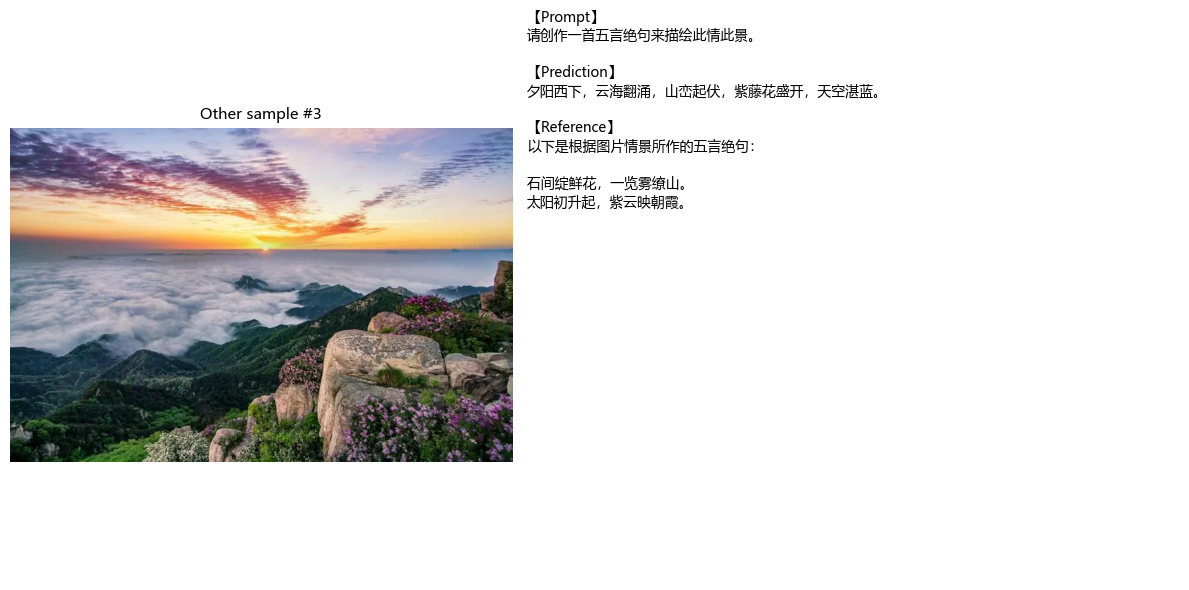

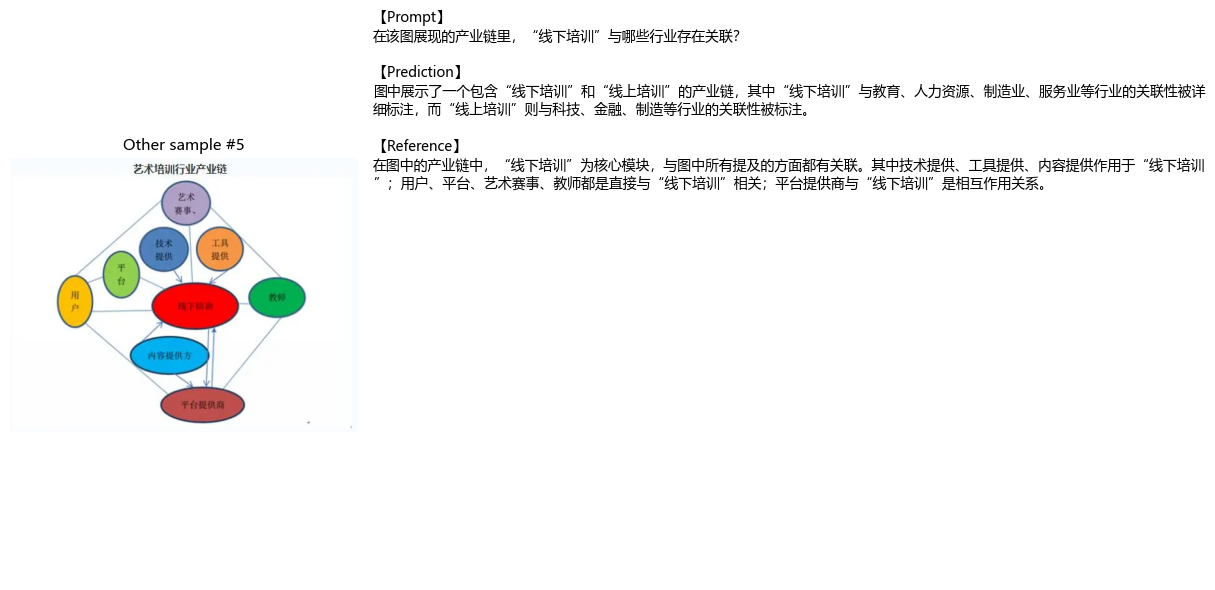

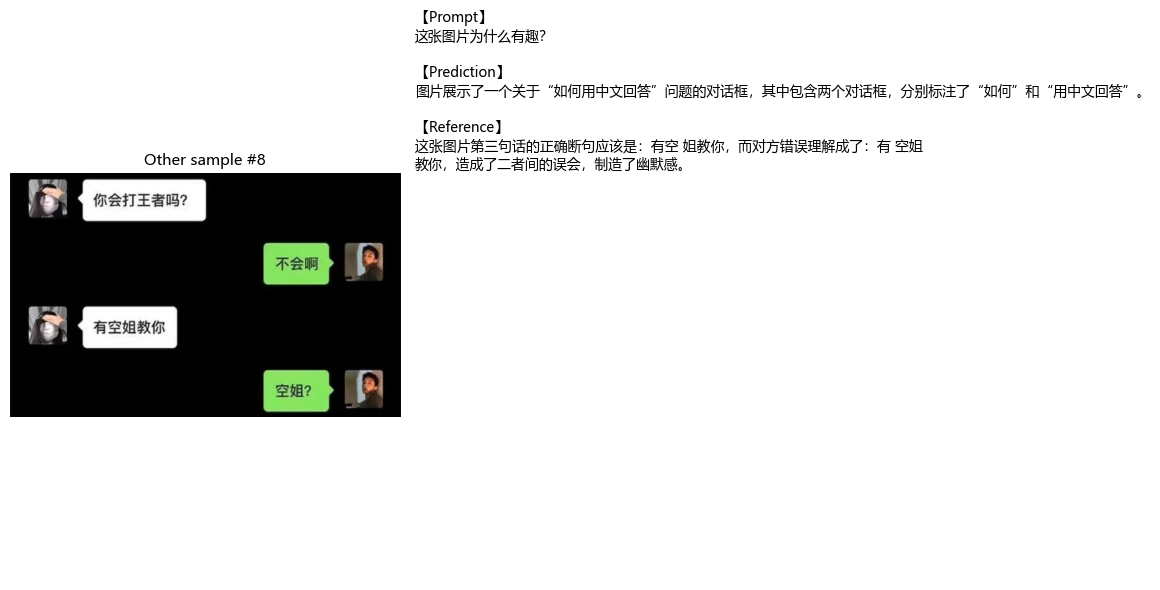

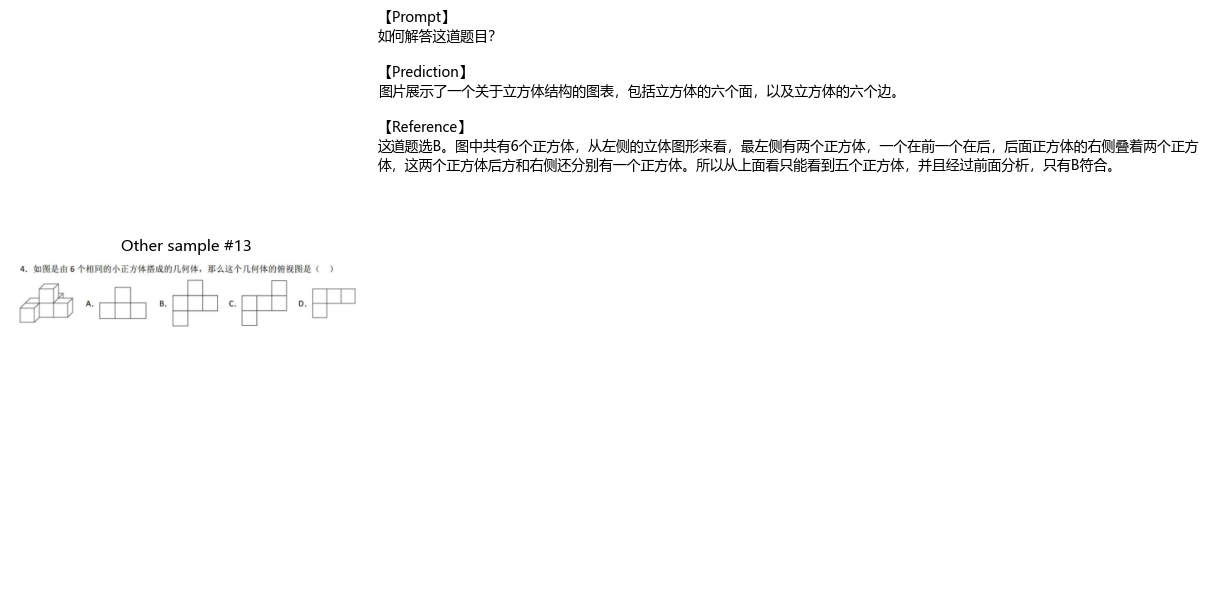

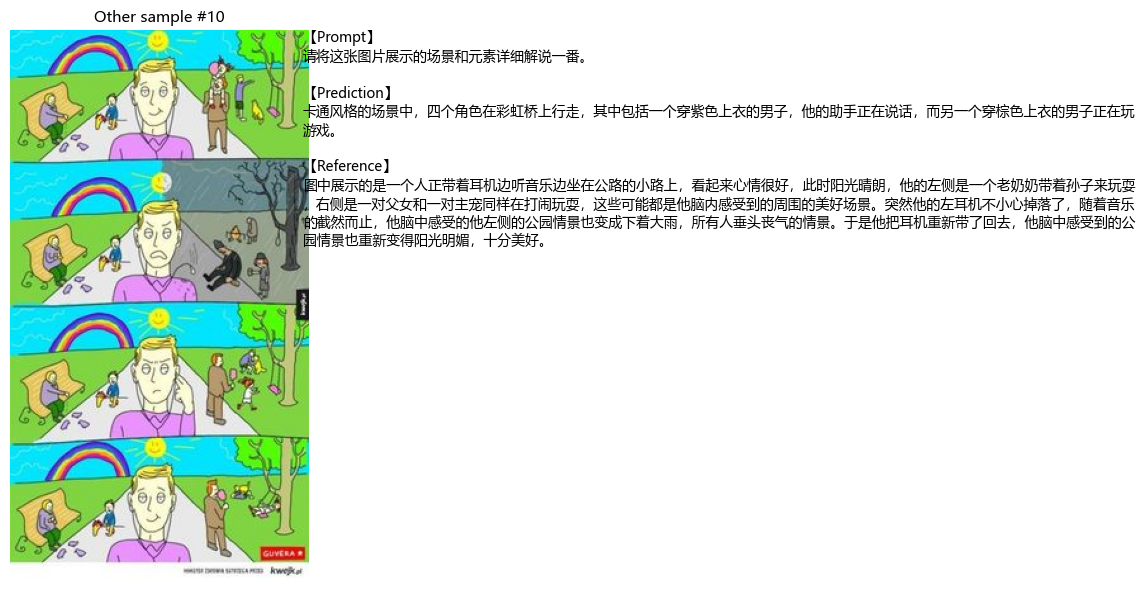

In [15]:
for r in other_results:
    show_sample(
        image=r['image'],
        prompt=r['prompt'],
        prediction=r['prediction'],
        reference=r['reference'],
        title=f"Other sample #{r['index']}",
    )

---
### 扩展提示

- 想换成其他数据源（例如 Cauldron 子集、ShareGPT-4o、lnqa 等），只需替换 `OTHER_MIX` 中的 `source / path / field` 键即可，加载接口完全一致。
- `VLModelInference.generate` 同时支持批量（传入列表）与单样本（直接传 `PIL.Image` + `str`），可按显存酌情改为批量推理。
- 若需要把结果保存为 JSONL，可直接调用 `qwen3smvl.inference.inference_vl_model.save_results`。